In [4]:
! pip install pandas numpy matplotlib scikit-learn seaborn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully!")


All libraries imported successfully!


In [7]:
# Load California Housing Dataset
housing = fetch_california_housing()

# Convert it into a DataFrame
dataset = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target column
dataset["Price"] = housing.target

# Display the first 5 rows
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
# Dataset information
print(dataset.info())


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [9]:
# Check for missing values
print(dataset.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


In [10]:
# Separate features and target
X = dataset.drop("Price", axis=1)
y = dataset["Price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (16512, 8)
Testing Set: (4128, 8)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [13]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Predictions
linear_predictions = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [14]:
# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Predictions
ridge_predictions = ridge_model.predict(X_test_scaled)

print("Ridge Regression model trained successfully!")

Ridge Regression model trained successfully!


In [15]:
# Decision Tree Regressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Predictions
tree_predictions = tree_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [16]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree"
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, ridge_predictions)),
        np.sqrt(mean_squared_error(y_test, tree_predictions))
    ],
    "R2 Score": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, ridge_predictions),
        r2_score(y_test, tree_predictions)
    ]
})

print(results)

               Model      RMSE  R2 Score
0  Linear Regression  0.745581  0.575788
1   Ridge Regression  0.745557  0.575816
2      Decision Tree  0.703033  0.622823


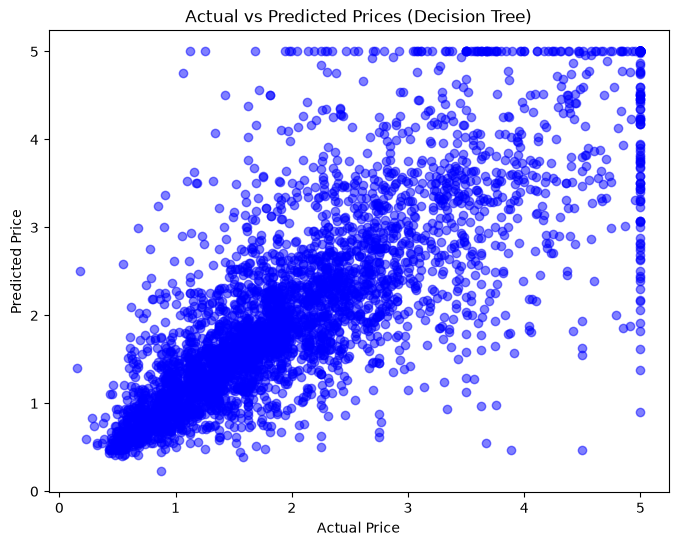

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, tree_predictions, color="blue", alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Decision Tree)")

plt.show()

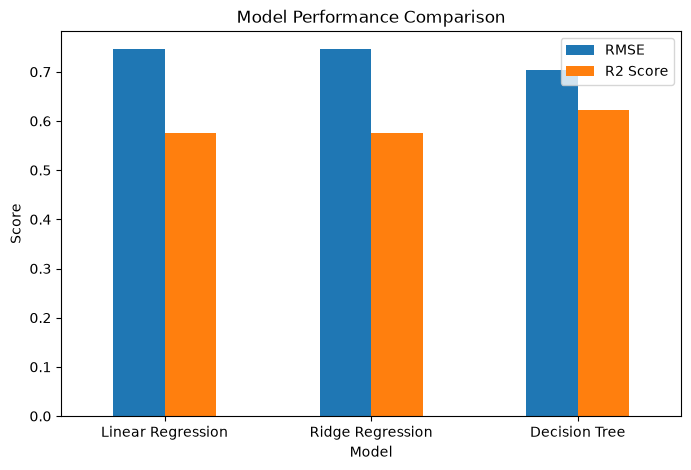

In [18]:
results.set_index("Model")[["RMSE", "R2 Score"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [19]:
sample = X.iloc[[0]]

prediction = tree_model.predict(sample)

print("Predicted House Price:", prediction[0])

Predicted House Price: 3.822
